<a href="https://colab.research.google.com/github/voronv27/projects-in-ai-and-ml/blob/main/HW6/Homework6_Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part 1: Reinforcement Learning

##Task 1

###Problem Definition:

I chose to use FrozenLake (with `isSlippery=True` and modified rewards) for this problem.

The state space in this problem is the 16 positions on the 4x4 grid that the agent can go to, which is represented with numbers 0 through 15 for each square on the grid. The action space in this problem is the 4 directions the agent can choose to move on the map: 0 represents left, 1 represents down, 2 represents right, and 3 represents up. The reward structure in the default FrozenLake problem is 1 for reaching the goal and 0 for everything else (falling into a hole and stepping on ice). However, to encourage my agent to be efficient in getting to the goal and avoid excessive wandering, I will add a -0.01 reward for stepping on ice (to encourage the agent to find the shortest path to the goal) and a -0.2 reward for falling in a hole (to better encourage the agent to avoid holes). Finally, I will use a fairly high discount factor of 0.95 to encourage my agent to think ahead and choose steps that offer future reward, even if they don't offer immediate reward.

In [133]:
from gymnasium.envs.toy_text.frozen_lake import generate_random_map
import gymnasium as gym

env = gym.make(
    'FrozenLake-v1',
    render_mode="rgb_array",
    desc=None,
    map_name="4x4",
    is_slippery=True,
    reward_schedule=(1, -0.2, -0.01) #goal = +1, hole = -0.2, ice = -0.01
)

In [134]:
# setting seeds for reproducability
seed = 42
env.action_space.seed(seed)

42

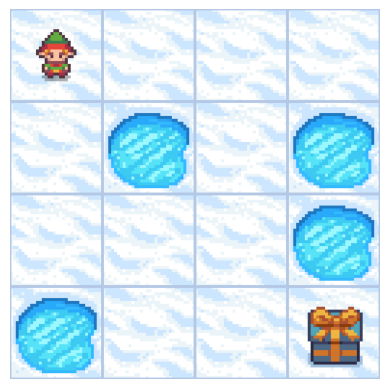

In [135]:
import matplotlib.pyplot as plt

obs, _ = env.reset(seed=seed)
frame = env.render()

plt.imshow(frame)
plt.axis('off')
plt.show()

###Value Iteration

In [136]:
import numpy as np

gamma = 0.95 # discount factor
theta = 1e-6

n_states = env.observation_space.n
n_actions = env.action_space.n

def val_iteration(V):
  while True:
    delta = 0
    new_V = np.copy(V)

    # iterate over all grid positions
    for state in range(n_states):
      action_values = []

      # iterate over all possible actions
      for action in range(n_actions):
        total_reward = 0

        # Since we have isSlippery, there's a probability of
        # the action failing. We sum the rewards for
        # succeeding/failing at taking the action
        for prob, next_state, reward, done in env.unwrapped.P[state][action]:
          if done:
            total_reward += prob * reward
          else:
            total_reward += prob * (reward + gamma * V[next_state])

        action_values.append(total_reward)

      # set V[state] to the best reward over all possible actions
      new_V[state] = max(action_values)
      delta = max(delta, abs(V[state] - new_V[state]))

    V = new_V

    # stop once change to V hits our theta threshold
    if delta < theta:
      break
  return V


In [137]:
V = np.zeros(n_states)
V = val_iteration(V)

In [138]:
# function to compute final policy
def compute_policy(V):
  policy = np.zeros(n_states)

  # for each state, select the "best action" which
  # corresponds to its value in V
  for state in range(n_states):
    best_action = 0
    best_value = -float("inf")
    for action in range(n_actions):
      total_reward = 0
      for prob, next_state, reward, done in env.unwrapped.P[state][action]:
        if done:
          total_reward += prob * reward
        else:
          total_reward += prob * (reward + gamma * V[next_state])

      if total_reward > best_value:
        best_value = total_reward
        best_action = action

    policy[state] = best_action
  return policy

In [139]:
policy = compute_policy(V)

###Learned Value Function and Final Policy:

Value Function
[[ 0.0166 -0.0143 -0.0158 -0.0409]
 [ 0.0508  0.      0.0117  0.    ]
 [ 0.1245  0.2496  0.2844  0.    ]
 [ 0.      0.4108  0.6684  0.    ]]


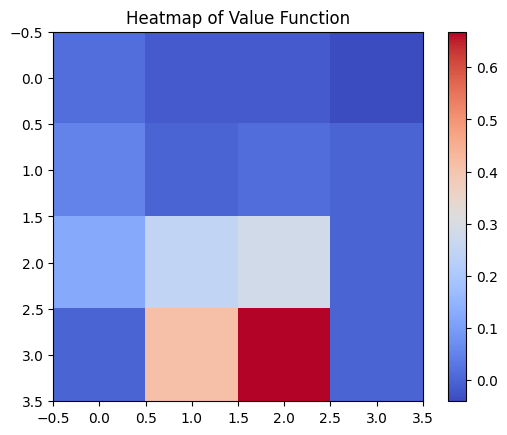

In [140]:
# visualize value function
n = int(np.sqrt(n_states))
V_grid = V.reshape(n, n)

print("Value Function")
print(np.round(V_grid, 4))

plt.imshow(V_grid, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.title("Heatmap of Value Function")
plt.show()

In [141]:
# visualize final policy
action_symbols = ["←", "↓", "→", "↑"]
desc = env.unwrapped.desc.astype(str)
policy_grid = policy.reshape(n, n)

print("Final Policy")
for i in range(n):
  for j in range(n):
    if desc[i][j] in ['H', 'G']:
      print(desc[i][j], end=' ')
    else:
      action = int(policy_grid[i][j])
      print(action_symbols[action], end=" ")
  print()

Final Policy
← ↑ ← ↑ 
← H → H 
↑ ↓ ← H 
H → ↓ G 


This learned policy really surprised me! It seems the agent is so focused on avoiding the holes and dealing with sliperiness that it doesn't actually try to walk its way down to the goal. Rather, it just avoids holes where it can and tries to slip its way to the goal.

Due to the sliperiness, being anywhere near a hole can result in falling down the hole even if the agent doesn't choose to walk into the hole (there is a 2/3 chance of slipping and going in one of the two perpendicular directions to the desired direction).

As such, we see that the policy's "best action" for state 14 (bottom row, second from right, and one tile left of the goal) is actually to try and go down, rather than to just go right and try to reach the goal. If the agent suceeds in going down, it will run into a wall and get to try again, and if it fails, it will go either left or right, with right leading to the goal (success), and left being a safe (non-hole) space. If it tries to go right, it has a similar 1/3 chance of success, a 1/3 chance to do nothing (go down and run into a wall) and a 1/3 chance to go up and land on a safe space (non-hole). However, looking at our value function, we can see that we have a higher chance of success from the tile left of state 14 than the tile above it (as visualized in the heatmap). As such, while both going right and down would result in a 1/3 chance of success, a 1/3 chance of staying in place and a 1/3 chance of going to a non-hole space, going down puts the agent in a better position for that non-hole space than going right and is therefore the better action to take.

Overall, I just think it's very interesting to see how the agent factors in the sliperiness of the lake when picking which direction it should travel in. There are many places where the learned policy seems counter-intuitive but would probably lead to the best chance of success when you think about it more.

###Run Small Experiment:

We will observe how the policy changes when we vary the discount factor.

Value Function
[[-0.0143 -0.0143 -0.0143 -0.0143]
 [-0.0142  0.     -0.0729  0.    ]
 [-0.0134 -0.0066  0.0187  0.    ]
 [ 0.      0.0288  0.3662  0.    ]]


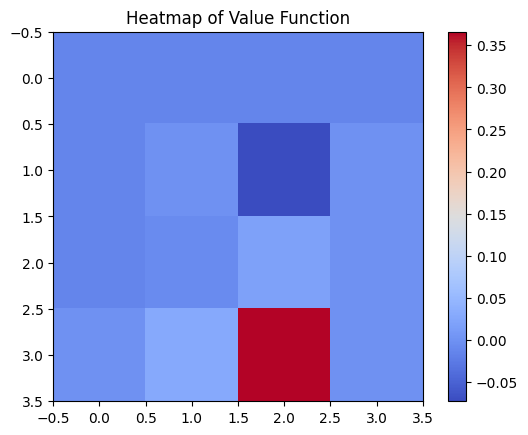


Final Policy
← ↑ ↑ ↑ 
← H ← H 
↑ ↓ ← H 
H → ↓ G 


In [149]:
gamma = 0.3
V = np.zeros(n_states)
V = val_iteration(V)
policy = compute_policy(V)

# visualize value function
n = int(np.sqrt(n_states))
V_grid = V.reshape(n, n)

print("Value Function")
print(np.round(V_grid, 4))

plt.imshow(V_grid, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.title("Heatmap of Value Function")
plt.show()

# visualize final policy
action_symbols = ["←", "↓", "→", "↑"]
desc = env.unwrapped.desc.astype(str)
policy_grid = policy.reshape(n, n)

print("\nFinal Policy")
for i in range(n):
  for j in range(n):
    if desc[i][j] in ['H', 'G']:
      print(desc[i][j], end=' ')
    else:
      action = int(policy_grid[i][j])
      print(action_symbols[action], end=" ")
  print()


I decreased the discount factor by a significant amount, meaning that the value function doesn't take future reward into account nearly as much. In the heatmap, we can see a drastic change in values. Outside of the square next to the goal, all other values are now much closer to uniform, compared to before where state 13 (bottom row, second from left) was still a fairly desirable state.

The policy still avoids holes and relies on slipping towards the goal, but it has some changes. The arrows that changed in the policy show that the agent prioritizes current reward/safety over possible future reward. For example, in the top row the agent doesn't choose to go left in state 2 (second from right) as it does in the previous learned policy and instead chooses to go up. Going up in this position will either lead to doing nothing, or going left/right to safe spaces if the agent slips. However, this action doesn't take the agent any closer to the goal, since the entire top row policy outside of the leftmost tile just allows the agent to go left/right and not down. So, they can slide around the top row for quite a while before reaching the leftmost tile that will actually take them downwards to the goal, accumulating penalties to their total reward. But with such a low discount rate, the agent doesn't factor in accumulated penalities for wandering around the top row as much. As such, it chooses to go up because it's safer in the short term, rather than taking into account long-term reward (when, at some point, it may honestly be better to fall in a hole and die than keep wandering for eternity in the top row).

###Discussion:

Our setup follows the Markov property in that future states depend only on the current state and action and not on the past--it doesn't matter how the agent reached a certain state, all that matters is future actions it can take to maximize reward from that point. It also has all the necessary components for a MDP: states, actions, a transition probability, rewards, and a discount factor. The states are positions on the grid, the actions are the directions the agent chooses to go, the transition probablity is the sliperiness (we have probabilities for each action leading to a state--i.e. we have a 1/3 probablity of "down" action leading to the state that is below on the grid, 1/3 probability of down action leading to the state that is to the left on the grid, and 1/3 probability of down leading to the state that is to the right on the grid), the reward function is the rewards we defined for reaching each state (non-goal, hole, and goal), and the discount factor is our `gamma` variable which changes how much immediate vs future rewards are prioritized (set to 0.95).

The learned policy maps each state to its "best action" at that state, with our actions being choosing to move up/down/left/right. The "best action" comes from the action that provides the best current reward + gamma * future reward. In this case, that means taking actions that avoid failure (falling into holes) and seek success (reaching the goal). Since falling into a hole means no recovery, our learned policy heavily prefers taking a longer, safer path over a faster but riskier path to the goal.